# Exploratory Data Analysis (EDA) – Fraud Detection

## 1. Import Libraries

In [1]:
# Core libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Load Dataset

In [2]:
data_path = "../data/raw/transactions_fraud.csv"

# Load cleaned transaction dataset
df = pd.read_csv(data_path)
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/24 19:23,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/24 2:22,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/24 17:26,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/24 16:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/24 23:14,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0


Insight:
- Each row represents a single transaction.
- The target variable is `is_fraud`.

## 3. Data Structure and Summary

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  50000 non-null  int64  
 1   customer_id                     50000 non-null  int64  
 2   device_id                       50000 non-null  int64  
 3   merchant_id                     50000 non-null  int64  
 4   timestamp                       50000 non-null  object 
 5   amount                          50000 non-null  float64
 6   payment_method                  50000 non-null  object 
 7   is_international                50000 non-null  int64  
 8   merchant_category               50000 non-null  object 
 9   ip_address_risk_score           50000 non-null  float64
 10  device_trust_score              50000 non-null  float64
 11  txn_count_last_24h              50000 non-null  int64  
 12  avg_amount_last_24h             

- `timestamp` is of object type so we will change it to datetime

In [4]:
# change timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%m/%d/%y %H:%M")

In [5]:
rename_map = {
    "txn_count_last_24h": "velocity_24h",
    "hour_of_day": "time_of_day"
}

df.rename(columns=rename_map, inplace=True)
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,velocity_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,time_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,2024-01-18 19:23:00,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,2024-03-30 02:22:00,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,2024-01-04 17:26:00,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,2024-01-27 16:00:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2024-02-20 23:14:00,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,50000.0,NaN,NaN,NaN,25000.5,1.0,12500.75,25000.5,37500.25,50000.0,14433.901067
customer_id,50000.0,NaN,NaN,NaN,2997.25424,1000.0,1994.0,3002.0,3996.0,4999.0,1155.746991
device_id,50000.0,NaN,NaN,NaN,25002.29148,20000.0,22513.0,25010.5,27496.0,29999.0,2883.264316
merchant_id,50000.0,NaN,NaN,NaN,650.02924,500.0,575.0,650.0,725.0,799.0,86.47709
timestamp,50000,NaN,NaN,NaN,2024-02-15 01:03:45.368399872,2024-01-01 00:01:00,2024-01-23 15:46:45,2024-02-15 03:35:30,2024-03-08 10:27:30,2024-03-30 23:55:00,NaN
amount,50000.0,NaN,NaN,NaN,10015.213203,50.51,5007.7125,9971.515,15017.2825,19999.08,5756.852793
payment_method,50000,4,UPI,27573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_international,50000.0,NaN,NaN,NaN,0.02958,0.0,0.0,0.0,0.0,1.0,0.169427
merchant_category,50000,6,Electronics,8399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_address_risk_score,50000.0,NaN,NaN,NaN,0.499724,0.000026,0.250929,0.498304,0.749212,0.999984,0.287707


**Key Insights**

- Transactions: 50,000 (no missing values)

- Fraud rate: 10.06%

- Amount: Mean = 10015.21 | Median = 9971.51 | Range: 50.51–19999.08 (well distributed)

- International transactions: 2.96% (rare feature)

- **Risk Scores (0–1 scale)**:

    - IP risk mean ≈ 0.50

    - Device trust mean ≈ 0.50

    - Merchant fraud rate mean ≈ 7.5%

- **Behavioral Metrics**:

    - Velocity (24h) mean ≈ 5.5

    - Merchant diversity (7d) mean ≈ 6

    - Device change: 8%

    - Location change: 9.9%

- **Customer History**:

    - Past fraud mean ≈ 1

    - Past disputes mean ≈ 2

    - OTP success rate mean ≈ 70%

Clean, balanced feature scales; main statistical issue is target imbalance.

## 4. Fraud vs Non-Fraud Distribution

Fraud counts:


is_fraud
0    44972
1     5028
Name: count, dtype: int64


Fraud ratio: 10.0560%


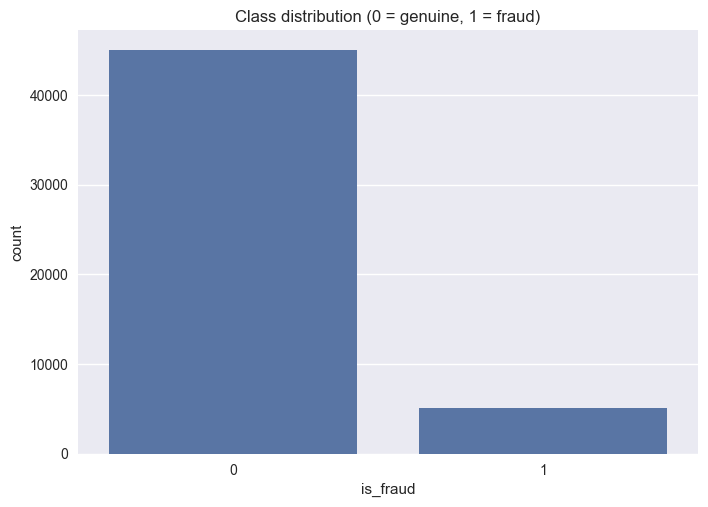

In [7]:
# Fraud vs non-fraud counts
fraud_counts = df["is_fraud"].value_counts()
fraud_ratio = df["is_fraud"].mean()

print("Fraud counts:")
display(fraud_counts)
print(f"\nFraud ratio: {fraud_ratio:.4%}")

# Visualize class imbalance
sns.countplot(x="is_fraud", data=df)
plt.title("Class distribution (0 = genuine, 1 = fraud)")
plt.show()

Insights:
- The dataset has a significant class imbalance with only 10.06% fraud cases.

## 5. Transaction Amount Distribution

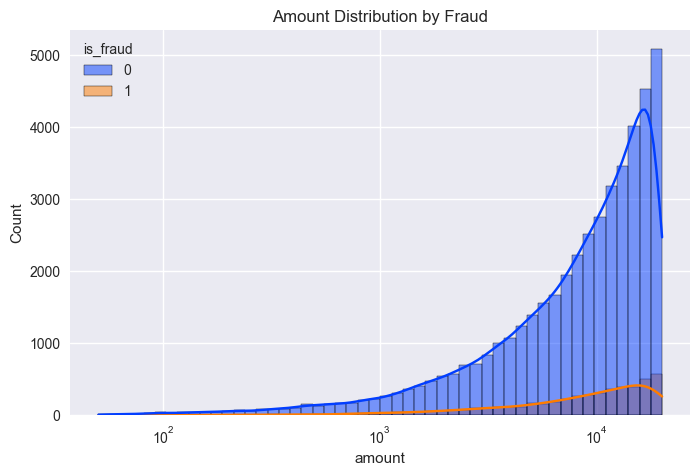

In [8]:
# Visualize overall transaction amount distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="amount", 
    palette="bright", 
    hue="is_fraud", 
    bins=50, 
    log_scale=True, # Log transform to reduce skewness
    kde=True
    )
plt.title("Amount Distribution by Fraud")
plt.show()

Insights:
- The log-transformed distribution of transaction amounts shows a clear right-skew

## 6. Amount vs Fraud Label

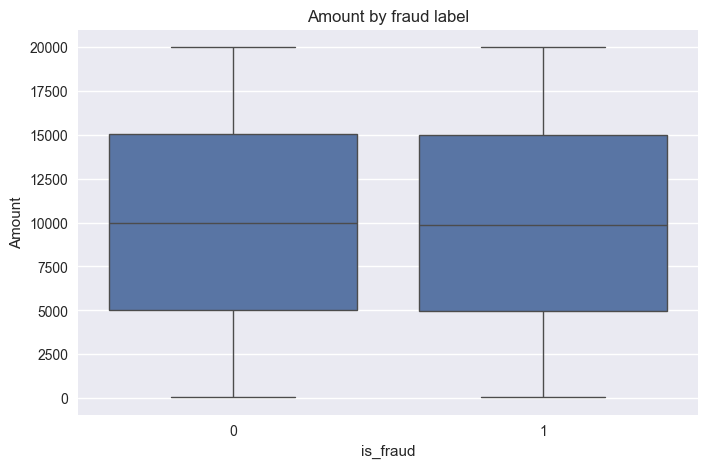

In [9]:
# Compare amount distribution between fraud and non-fraud
plt.figure(figsize=(8, 5))
sns.boxplot(x="is_fraud", y="amount", data=df)
plt.title("Amount by fraud label")
plt.xlabel("is_fraud")
plt.ylabel("Amount")
plt.show()

- No visible differences in amount distribution.
- We will now use violin plot to check the minor differences.

In [10]:
df["log_amount"] = np.log1p(df["amount"])

fig = px.violin(
    df,
    x="is_fraud",
    y="log_amount",
    color="is_fraud",
    box=True,
    points="all",
)

fig.update_layout(
    title="Log Transaction Amount by Fraud Label",
    xaxis_title="Fraud Label",
    yaxis_title="log(1 + Amount)",
)

fig.show()

Insight: 
- The violin plots of log-transformed transaction amounts reveal no distinct patterns or significant differences in distribution between fraudulent and genuine transactions.

Reason:
- The distribution of log_amount for both fraudulent and genuine transactions largely overlap.

Conclusion:
- This suggests that, in this dataset, the transaction amount alone is not a strong indicator to distinguish between fraud and non-fraud. 
- Both types of transactions seem to occur across similar value ranges.

## 7. Device and Customer Behavior Patterns

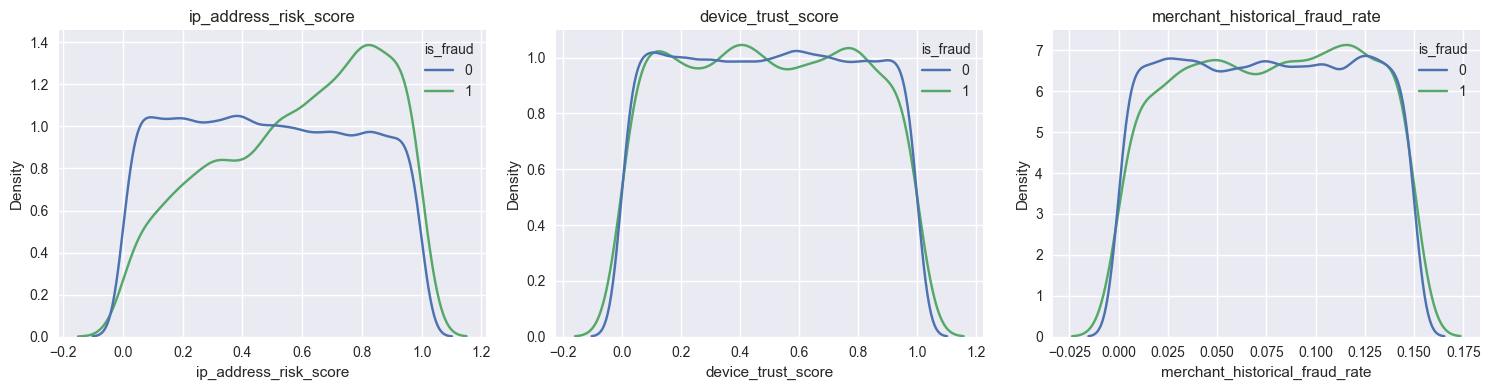

In [11]:
# Check if shared devices are linked to fraud
risk_cols = [
    "ip_address_risk_score",
    "device_trust_score",
    "merchant_historical_fraud_rate",
]

fig, axes = plt.subplots(1, len(risk_cols), figsize=(5 * len(risk_cols), 4))
for ax, col in zip(axes, risk_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue="is_fraud",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [12]:
device_trust_stats = df.groupby('is_fraud')['device_trust_score'].describe()
display(device_trust_stats)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,44972.0,0.498971,0.289081,0.000004,0.247317,0.501062,0.747815,0.999948
1,5028.0,0.496371,0.289662,0.000275,0.246755,0.490855,0.748817,0.999677


In [13]:
ip_risk_stats = df.groupby('is_fraud')['ip_address_risk_score'].describe()
display(ip_risk_stats)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,44972.0,0.490379,0.287537,0.000026,0.240816,0.484603,0.737848,0.999984
1,5028.0,0.583308,0.275493,0.000235,0.360295,0.623333,0.819059,0.999782


In [14]:
merchant_fraud_stats = df.groupby('is_fraud')['merchant_historical_fraud_rate'].describe()
display(merchant_fraud_stats)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,44972.0,0.074924,0.043390,0.000008,0.037158,0.074927,0.112686,0.149995
1,5028.0,0.077097,0.043213,0.000032,0.040020,0.078522,0.114883,0.149972


Insights: 
- The KDE plots for `ip_address_risk_score`, `device_trust_score`, and `merchant_historical_fraud_rate` show distinct shifts in distribution. 
- With higher scores generally observed for fraudulent transactions, indicating their strong predictive value.

In [15]:
def fraud_rate_by(col):
    tmp = (
        df.groupby(col)["is_fraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "count"})
        .sort_values("fraud_rate", ascending=False)
    )
    return tmp

In [16]:
fraud_rate_by("merchant_category")

,fraud_rate,count
merchant_category,,
Utilities,0.103452,8226
Gaming,0.102537,8397
Electronics,0.101083,8399
Grocery,0.100432,8334
Fashion,0.098146,8253
Travel,0.097724,8391


Insights:
- Fraud rates across merchant categories are quite uniform, all hovering around 10%. 
- This suggests that merchant_category is not a strong indicator for fraud in this dataset.

In [17]:
fraud_rate_by("is_international")

,fraud_rate,count
is_international,,
1,0.130494,1479
0,0.099648,48521


Insight:
- International transactions (is_international = 1) have a higher fraud rate of approximately 13.05% compared to domestic transactions (is_international = 0), which have a fraud rate of around 9.96%. 
- This indicates that international transactions are slightly more prone to fraud in this dataset.

## 8. Fraud Rate by Payment Method

In [18]:
fraud_rate_by("payment_method")

,fraud_rate,count
payment_method,,
NETBANKING,0.103899,5053
UPI,0.101440,27573
CARD,0.098682,12444
WALLET,0.096957,4930


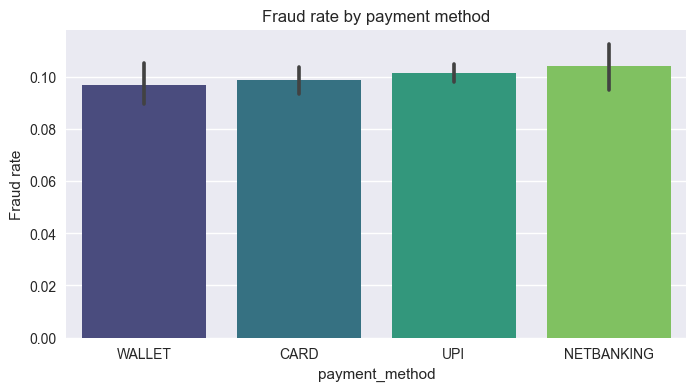

In [19]:
# Calculate fraud rate per payment method
plt.figure(figsize=(8, 4))
sns.barplot(
    x="payment_method",
    y="is_fraud",
    data=df,
    estimator=np.mean,
    errorbar="ci",
    palette="viridis",
    hue="payment_method",
    legend=False
)
plt.title("Fraud rate by payment method")
plt.ylabel("Fraud rate")
plt.show()

Insights: 
- Fraud rates are largely consistent across all payment methods (ranging from 9.7% to 10.4%).
- This suggests that payment method alone is not a strong indicator of fraud.

## 9. Fraud Rate by Hour of Day

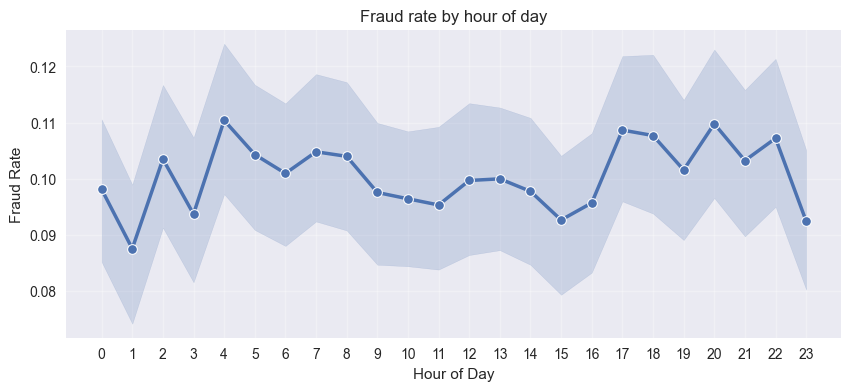

In [20]:
# Analyze fraud behavior across 24 hours
plt.figure(figsize=(10, 4))
sns.lineplot(
    x="time_of_day",
    y="is_fraud",
    data=df,
    estimator=np.mean,
    marker="o",
    linewidth=2.5
)
plt.title("Fraud rate by hour of day")
plt.ylabel("Fraud Rate")
plt.xlabel("Hour of Day")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

In [21]:
# Calculate fraud rate by hour of day
hourly_fraud_rate = df.groupby('time_of_day')['is_fraud'].mean().sort_values(ascending=False)

# Identify peak fraud hour(s)
peak_fraud_hour = hourly_fraud_rate.idxmax()
peak_fraud_rate = hourly_fraud_rate.max()

# Identify lowest fraud hour(s)
lowest_fraud_hour = hourly_fraud_rate.idxmin()
lowest_fraud_rate = hourly_fraud_rate.min()

print(f"Peak fraud hour(s): {peak_fraud_hour} (Fraud Rate: {peak_fraud_rate:.4%})")
print(f"Lowest fraud hour(s): {lowest_fraud_hour} (Fraud Rate: {lowest_fraud_rate:.4%})")

# Display top and bottom 5 hours by fraud rate for more context
print("\nTop 5 hours by fraud rate:")
print(hourly_fraud_rate.head())

print("\nBottom 5 hours by fraud rate:")
print(hourly_fraud_rate.tail())

Peak fraud hour(s): 4 (Fraud Rate: 11.0409%)
Lowest fraud hour(s): 1 (Fraud Rate: 8.7580%)

Top 5 hours by fraud rate:
time_of_day
4     0.110409
20    0.109802
17    0.108674
18    0.107707
22    0.107212
Name: is_fraud, dtype: float64

Bottom 5 hours by fraud rate:
time_of_day
11    0.095352
3     0.093735
15    0.092681
23    0.092457
1     0.087580
Name: is_fraud, dtype: float64


Insights:
- The peak fraud hour is **4 AM**, with a fraud rate of **11.04%**. 
- The lowest fraud hour is **1 AM**, with a fraud rate of **8.76%**. 
- The **top 5** hours with the highest fraud rates are **4, 20, 17, 18, and 22**.

## 10. Fraud Rate by Day of Week

In [22]:
# Display quantitative fraud rates by day of week
print("\nFraud rates by day of week:")
display(fraud_rate_by("day_of_week"))


Fraud rates by day of week:


,fraud_rate,count
day_of_week,,
5,0.108702,7148
0,0.103860,7125
6,0.101403,6558
1,0.099556,7212
3,0.097779,7384
2,0.097415,7350
4,0.095528,7223


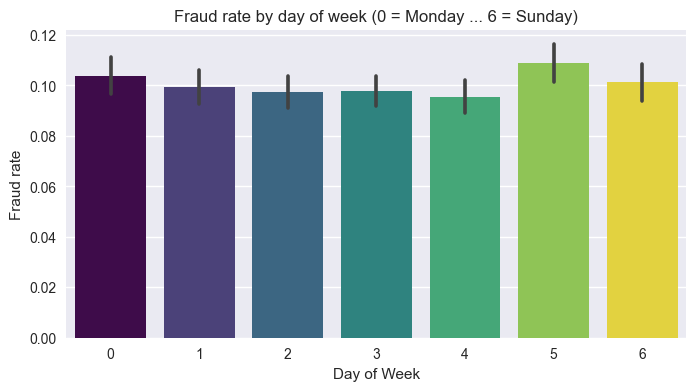

In [23]:
# Analyse fraud behavior across days of week
plt.figure(figsize=(8, 4))
sns.barplot(
    x="day_of_week",
    y="is_fraud",
    data=df,
    estimator=np.mean,
    palette="viridis",
    hue="day_of_week",
    legend=False
)
plt.title("Fraud rate by day of week (0 = Monday ... 6 = Sunday)")
plt.ylabel("Fraud rate")
plt.xlabel("Day of Week")
plt.show()

Insights: 
- The fraud rates show slight variations across the days of the week. 
- Weekends (**Day 5**, **Saturday**, at **10.87%**) tend to have slightly higher fraud rates compared to weekdays, with **Day 4 (Friday)** showing the lowest rate **(9.55%)**.
-  While there are differences, the overall range of fraud rates is not dramatically spread out, suggesting that day of the week is a minor indicator of fraud in this dataset.



## 11. Fraud Rate: Weekday vs Weekend

In [24]:
# Display quantitative fraud rates by weekday vs weekend
print("\nFraud rates by Weekday (0) vs Weekend (1):")
display(df.groupby('is_weekend')['is_fraud'].mean())


Fraud rates by Weekday (0) vs Weekend (1):


is_weekend
0    0.098804
1    0.105209
Name: is_fraud, dtype: float64

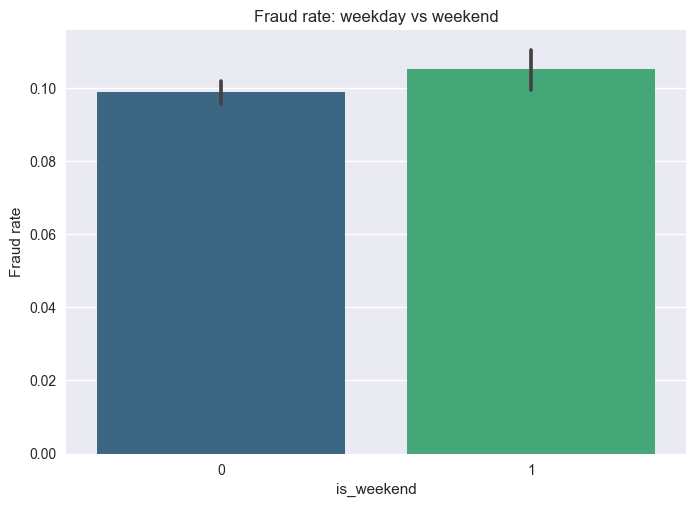

In [25]:
# Fraud rate: Weekday vs Weekend
sns.barplot(
    x="is_weekend",
    y="is_fraud",
    data=df,
    estimator=np.mean,
    palette="viridis",
    hue="is_weekend",
    legend=False
)
plt.title("Fraud rate: weekday vs weekend")
plt.ylabel("Fraud rate")
plt.show()

Insights: 
- The fraud rate is slightly higher on weekends **(10.52%)** compared to weekdays **(9.88%)**. 
- This difference suggests a minor but observable trend in fraud behavior related to the day of the week.

## 12. Fraud vs 24-Hour Transaction Velocity

In [26]:
velocity_stats = df.groupby('is_fraud')['velocity_24h'].describe()
display(velocity_stats)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,44972.0,5.497554,3.437724,0.0,3.0,6.0,8.0,11.0
1,5028.0,5.481504,3.477721,0.0,2.0,5.0,9.0,11.0


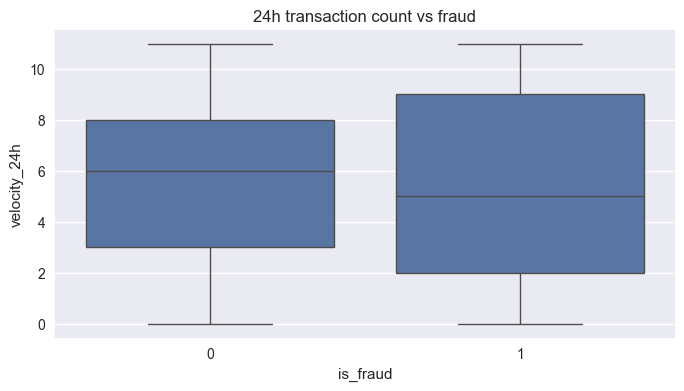

In [27]:
## Transaction Velocity (Last 24 Hours) by Fraud Label
plt.figure(figsize=(8, 4))
sns.boxplot(x="is_fraud", y="velocity_24h", data=df)
plt.title("24h transaction count vs fraud")
plt.show()

Insights: 
- The box plot shows that fraudulent transactions tend to have a higher median and wider distribution of velocity_24h compared to non-fraudulent ones. 
- This indicates that a higher number of transactions within a short period can be a strong indicator of fraudulent activity.

## 13. Fraud vs Merchant Diversity (Last 7 Days)

In [28]:
merchant_diversity_stats = df.groupby('is_fraud')['merchant_diversity_last_7d'].describe()
display(merchant_diversity_stats)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,44972.0,5.967624,3.156692,1.0,3.0,6.0,9.0,11.0
1,5028.0,5.894988,3.163742,1.0,3.0,6.0,9.0,11.0


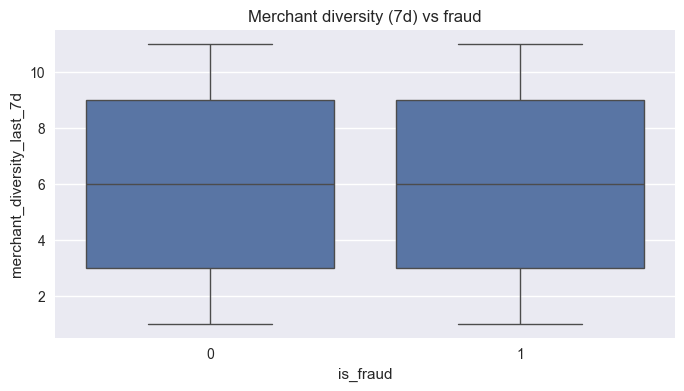

In [29]:
# Merchant Diversity in the Past 7 Days by Fraud Label
plt.figure(figsize=(8, 4))
sns.boxplot(x="is_fraud", y="merchant_diversity_last_7d", data=df)
plt.title("Merchant diversity (7d) vs fraud")
plt.show()

## 14. Correlation Analysis

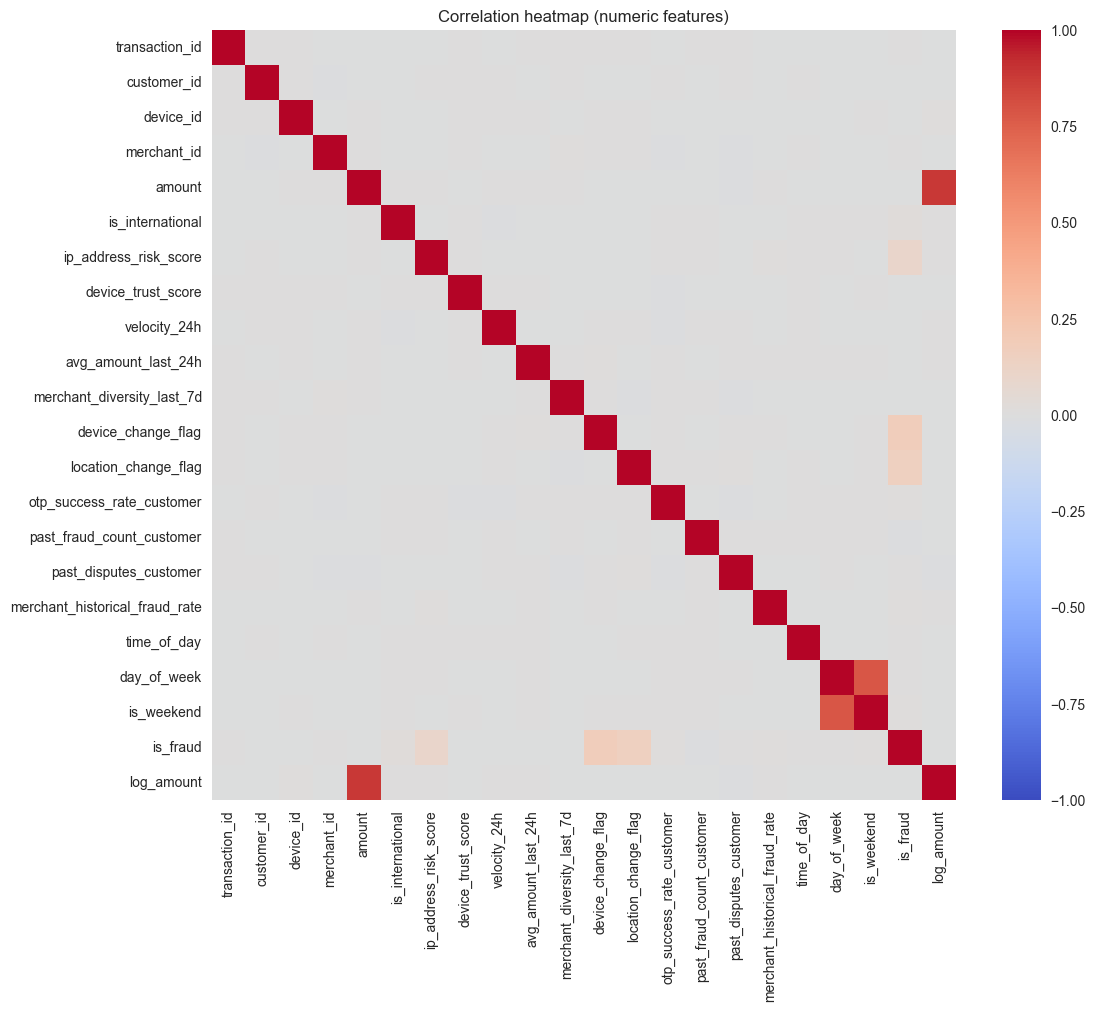

In [30]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

# Check relationships between numeric features
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0.0,
    vmax=1.0,
    vmin=-1.0,
    square=False,
)
plt.title("Correlation heatmap (numeric features)")
plt.show()

Insights:
- **Strongest Predictors**: `device_change_flag` **(0.179)**, `location_change_flag` **(0.153)**, and `ip_address_risk_score` **(0.097)** show the strongest positive linear relationships with fraud.
- **Weak to Negligible**: Most other features, including amount, `velocity_24h`, `device_trust_score`, and `merchant_diversity_last_7d`, exhibit very weak or negligible linear correlations with is_fraud.

In [31]:
# Save cleaned data for modeling
df.to_csv("../data/interim/transactions_clean.csv", index=False)
print("Cleaned data saved to ../data/interim/transactions_clean.csv")

Cleaned data saved to ../data/interim/transactions_clean.csv
